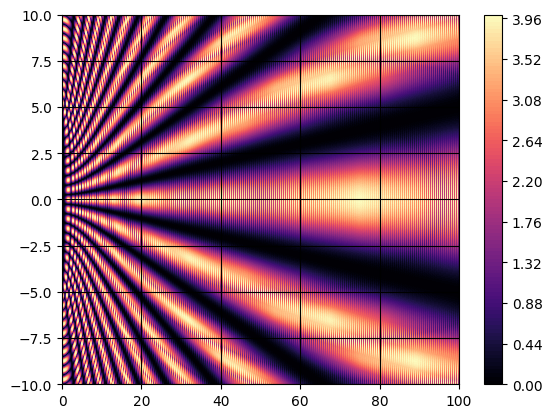

In [2]:
# Here I am going to do some sandbox stuffs on electric field and its relationship with potential

#Some basic plots on Gradient of a scaler fn()




import sympy as sp 
from sympy.vector import CoordSys3D,gradient
import numpy as np
import matplotlib.pyplot as plt




N=CoordSys3D('N')

x,y,z=N.base_scalars()

#position of slits

s1=(0,5,0)
s2=(0,-5,0)

ω=2*sp.pi


r1 = sp.sqrt((x-s1[0])**2 + (y-s1[1])**2 + (z-s1[2])**2) 
o1= sp.sin(ω*r1)

r2 = sp.sqrt((x-s2[0])**2 + (y-s2[1])**2 + (z-s2[2])**2)
o2= sp.sin(ω*r2)

v1=sp.lambdify((x,y,z),o1,"numpy")
v2=sp.lambdify((x,y,z),o2,"numpy")






def f(x,y,z):

    a=v1(x,y,z)+v2(x,y,z)

    return a


y=np.linspace(-10,10,1000)
x=np.linspace(0,100,1000)

X,Y=np.meshgrid(x,y)

Z=0




plt.contourf(X,Y,f(X,Y,Z)**2,levels=100,cmap="magma")

plt.plot(s1[0],s1[1])
plt.plot(s2[0],s2[1])

plt.grid(True,color="black")
plt.colorbar()



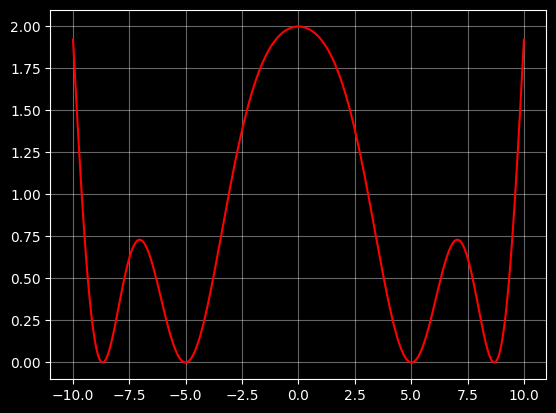

In [3]:

plt.style.use('dark_background')
plt.plot(y,f(100,y,Z)**2,color="red")


plt.grid(True,color="white",alpha=0.4)

# Time dependence

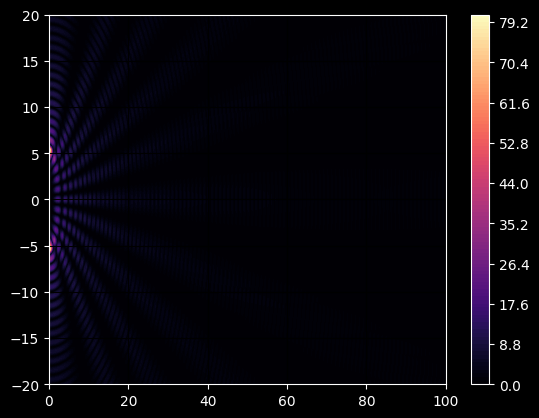

In [4]:
# Here I am going to do some sandbox stuffs on electric field and its relationship with potential

#Some basic plots on Gradient of a scaler fn()



from matplotlib.animation import FuncAnimation
import sympy as sp 
import numpy as np
import matplotlib.pyplot as plt




x,y,z,t=sp.symbols("x y z t")

#position of slits

s1=(0,5,0)
s2=(0,-5,0)

v=3*(10**8)
A=5
k=sp.pi
ω=v*k

r1 = sp.sqrt((x-s1[0])**2 + (y-s1[1])**2 + (z-s1[2])**2) 
o1= A*sp.sin(ω*t-k*r1)/sp.sqrt(r1)

r2 = sp.sqrt((x-s2[0])**2 + (y-s2[1])**2 + (z-s2[2])**2)
o2= A*sp.sin(ω*t-k*r2)/sp.sqrt(r2)

v1=sp.lambdify((x,y,z,t),o1,"numpy")
v2=sp.lambdify((x,y,z,t),o2,"numpy")






def f(x,y,z,t):

    a=v1(x,y,z,t)+v2(x,y,z,t)

    return a**2


y=np.linspace(-20,20,300)
x=np.linspace(0,100,300)
t=np.linspace(0,20,200)

X,Y=np.meshgrid(x,y)

Z=0

fig,axis=plt.subplots()
axis.set_xlim([min(x),max(x)])
axis.set_ylim([min(y),max(y)])


plot=axis.contourf(X,Y,f(X,Y,Z,0),levels=100,cmap="magma")
plt.colorbar(plot, ax=axis)

def update(frame):
    axis.clear()

    t_now = t[frame]
    contour = axis.contourf(X, Y, f(X,Y,Z,t_now), levels=100, cmap="magma")
    


    
    


animation=FuncAnimation(fig=fig,func=update,frames=len(t),interval=10,repeat=False,blit=False)




plt.grid(True,color="black")
plt.show()

animation.save("int.gif",writer="pillow",fps=30)


MovieWriter ffmpeg unavailable; using Pillow instead.


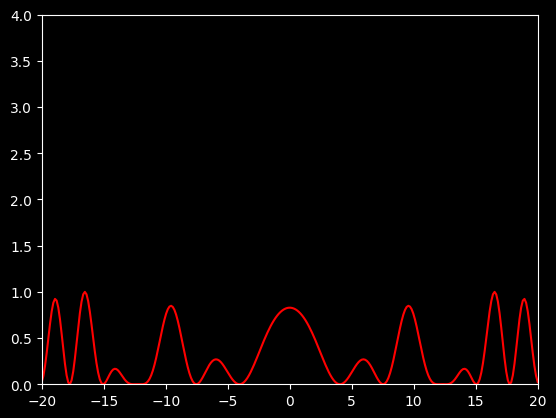

In [5]:
plt.style.use('dark_background')

fig, axis = plt.subplots()

plot, = axis.plot(y, np.zeros_like(y), color="red")

axis.set_xlim(min(y), max(y))
axis.set_ylim(0, 4)   # intensity range (since max = (2A)^2 = 4)
avg = np.mean([f(40,y,0,ti) for ti in t[:50]], axis=0)

def update_sc(frame):
    t_now = t[frame]
    intensity = f(40, y, 0, t_now)
    I=intensity/max(intensity)
    
    plot.set_data(y, I)
    return plot,

animation = FuncAnimation(fig=fig,
                          func=update_sc,
                          frames=len(t),
                          interval=10,
                          repeat=False)

animation.save("I.gif")

In [10]:
o1

5*sin(300000000*pi*t - pi*sqrt(x**2 + z**2 + (y - 5)**2))/(x**2 + z**2 + (y - 5)**2)**(1/4)

In [11]:
o2

5*sin(300000000*pi*t - pi*sqrt(x**2 + z**2 + (y + 5)**2))/(x**2 + z**2 + (y + 5)**2)**(1/4)